# Imports

In [2]:
import sys
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt
current_dir = os.path.dirname(os.getcwd())
sys.path.append(os.path.abspath(os.path.join(current_dir, '../')))

from openradar.mmwave.dataloader import DCA1000
from openradar.mmwave import dsp
from openradar.mmwave.dsp.utils import Window

# Configurations

In [11]:
# Configuration & File Paths
DATA_PATH = "../../data/Mobie_data_8_june/adc_data_2026-06-08_14-47-41_PHONE_VIB_42CM_NEW.npy"
save_dir = "../../Simulations/Radar/Phone_data_8_june/capon_beamformed_phases/Vibration_42cm"
os.makedirs(save_dir, exist_ok=True)
numFrames = 600
numADCSamples = 256
numTxAntennas = 3
numRxAntennas = 4
numLoopsPerFrame = 182
numChirpsPerFrame = numTxAntennas * numLoopsPerFrame

# Object Angle in degrees
OBJ_ANGLE = 0.0 

# Capon Beamforming functions

In [12]:
def gen_steering_vec(ang_est_range, ang_est_resolution, num_ant):
    """Vectorized Steering Vector Generation"""
    num_vec = int(round(2 * ang_est_range / ang_est_resolution + 1))
    angles_rad = np.radians(np.linspace(-ang_est_range, ang_est_range, num_vec))
    ant_indices = np.arange(num_ant)
    
    mag = -np.pi * np.outer(ant_indices, np.sin(angles_rad))
    steering_vectors = np.exp(1j * mag).T
    
    return num_vec, steering_vectors

def cov_matrix(x):
    if x.ndim > 2:
        raise ValueError("x has more than 2 dimensions.")
    if x.shape[0] > x.shape[1]:
        warnings.warn("cov_matrix input should have Vrx as rows. Needs to be transposed", RuntimeWarning)
        x = x.T
    _, num_adc_samples = x.shape
    Rxx = x @ np.conjugate(x.T)
    Rxx = np.divide(Rxx, num_adc_samples)
    return Rxx

def forward_backward_avg(Rxx):
    assert np.size(Rxx, 0) == np.size(Rxx, 1)
    M = np.size(Rxx, 0)  
    Rxx = np.matrix(Rxx)  
    J = np.fliplr(np.eye(M))  
    J = np.matrix(J)  
    R_fb = 0.5 * (Rxx + J * np.conjugate(Rxx) * J)
    return np.array(R_fb)

def aoa_capon(x, steering_vector, magnitude=False):
    if steering_vector.shape[1] != x.shape[0]:
        raise ValueError("'steering_vector' shape mismatch.")

    Rxx = cov_matrix(x)
    Rxx = forward_backward_avg(Rxx)
    
    diagonal_loading = 1e-3 * np.trace(Rxx) * np.eye(x.shape[0])
    Rxx_loaded = Rxx + diagonal_loading
    Rxx_inv = np.linalg.inv(Rxx_loaded)
    
    first = Rxx_inv @ steering_vector.T
    den = np.reciprocal(np.einsum('ij,ij->i', steering_vector.conj(), first.T))
    weights = first * den
    
    if magnitude:
        return np.abs(den), weights
    else:
        return den, weights

# Range bin detections

In [13]:
def iterative_range_bins_detection(rangeResult, min_bin=10, max_bin=None):
    rangeResult = np.transpose(np.stack([rangeResult[0::3], rangeResult[1::3], rangeResult[2::3]], axis=1), axes=(1,2,0,3))
    range_result_absnormal_split = []
    
    for i in range(numTxAntennas):
        for j in range(numRxAntennas):
            r_r = np.abs(rangeResult[i][j])
            r_r[:, :min_bin] = 0 
            if max_bin is not None:
                r_r[:, max_bin:] = 0 
                
            min_val, max_val = np.min(r_r), np.max(r_r)
            r_r_normalise = np.zeros_like(r_r) if max_val == min_val else (r_r - min_val) / (max_val - min_val) * 1000
            range_result_absnormal_split.append(r_r_normalise)
    
    range_abs_combined_nparray = np.sum(range_result_absnormal_split, axis=0) / (numTxAntennas * numRxAntennas)
    range_abs_combined_nparray_collapsed = np.sum(range_abs_combined_nparray, axis=0) / numLoopsPerFrame
    peaks_min_intensity_threshold = np.argsort(range_abs_combined_nparray_collapsed)[::-1][:max_bin-min_bin]
    max_range_index = np.argmax(range_abs_combined_nparray_collapsed)
    
    return max_range_index, peaks_min_intensity_threshold, rangeResult

In [14]:
frame_index = 2

# Main execution

In [15]:
loaded_adc_data = np.load(DATA_PATH)
current_frame = loaded_adc_data[frame_index-1:frame_index]

adc_data = np.apply_along_axis(DCA1000.organize, 1, current_frame,num_chirps=numChirpsPerFrame, num_rx=numRxAntennas, num_samples=numADCSamples)
radar_cube = dsp.range_processing(adc_data[0], window_type_1d=Window.BLACKMAN)

min_b = 5
max_b = 30
_, selected_bins, rangeResult = iterative_range_bins_detection(radar_cube, min_bin=min_b, max_bin=max_b)
bin_to_process = selected_bins[0]  
print(f"Top 10 sorted bins targeted: {selected_bins[:10]}")
print(f"Bin in consideration : {bin_to_process}")

scan_range_deg = 60
resolution_deg = 1
num_virtual_antennas = numTxAntennas * numRxAntennas   
num_vec, steering_vectors = gen_steering_vec(scan_range_deg, resolution_deg, num_virtual_antennas)
angles_grid = np.linspace(-scan_range_deg, scan_range_deg, num_vec)

x_slice = rangeResult[:, :, :, bin_to_process].reshape(num_virtual_antennas, numLoopsPerFrame) 

capon_spectrum, capon_weights_matrix = aoa_capon(x_slice, steering_vectors, magnitude=True)
capon_spectrum_dB = 10 * np.log10(capon_spectrum / np.max(capon_spectrum))

# According to given angle
target_angle_idx = np.argmin(np.abs(angles_grid - OBJ_ANGLE))
actual_steered_angle = angles_grid[target_angle_idx]  

w_opt_steered = capon_weights_matrix[:, target_angle_idx]
filtered_signal_steered = np.dot(w_opt_steered.conj().T, x_slice)
capon_filtered_phase_steered = np.unwrap(np.angle(filtered_signal_steered))

# According to peak after capon
peak_angle_idx = np.argmax(capon_spectrum)
dynamic_peak_angle = angles_grid[peak_angle_idx]

w_opt_dynamic = capon_weights_matrix[:, peak_angle_idx]
filtered_signal_dynamic = np.dot(w_opt_dynamic.conj().T, x_slice)
capon_filtered_phase_dynamic = np.unwrap(np.angle(filtered_signal_dynamic))

Top 10 sorted bins targeted: [12 13 23 11 24 22 21 14 16 26]
Bin in consideration : 12


# Capon spectrum and phase plot

In [16]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Top Plot: The Capon Spatial Spectrum
ax1.plot(angles_grid, capon_spectrum_dB, color='teal', linewidth=2)
ax1.axvline(actual_steered_angle, color='red', linestyle='--', alpha=0.7, 
            label=f'Steered (OBJ_ANGLE): {actual_steered_angle:.1f}°')
ax1.axvline(dynamic_peak_angle, color='orange', linestyle='-', alpha=0.9, 
            label=f'True Peak (Dynamic): {dynamic_peak_angle:.1f}°')
ax1.set_title(f"Range Bin: {bin_to_process} | Capon Spatial Spectrum")
ax1.set_xlabel("Angle (Degrees)")
ax1.set_ylabel("Power Density (dB)")
ax1.set_ylim(-35, 5)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend()

# Bottom Plot: Phase Comparison
ax2.plot(capon_filtered_phase_steered, color='red', marker='.', markersize=4, linestyle='-', alpha=0.7,
            label=f'Phase at {actual_steered_angle:.1f}° (Hardcoded)')
ax2.plot(capon_filtered_phase_dynamic, color='orange', marker='+', markersize=6, linestyle='-', alpha=0.9,
            label=f'Phase at {dynamic_peak_angle:.1f}° (True Peak)')
ax2.set_title(f"Phase Comparison: Steered Angle vs. Dynamic Peak")
ax2.set_xlabel("Chirp Index")
ax2.set_ylabel("Unwrapped Phase (Radians)")
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend()

fig.tight_layout()
fig.savefig(os.path.join(save_dir, f"frame{frame_index}_bin{bin_to_process}_phase_comparison.png"))
plt.close(fig)


Tracking dynamic Capon phase for 10 Bins: [7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
Processing frames 1 to 200...
Processing complete. Generating phase difference plot...


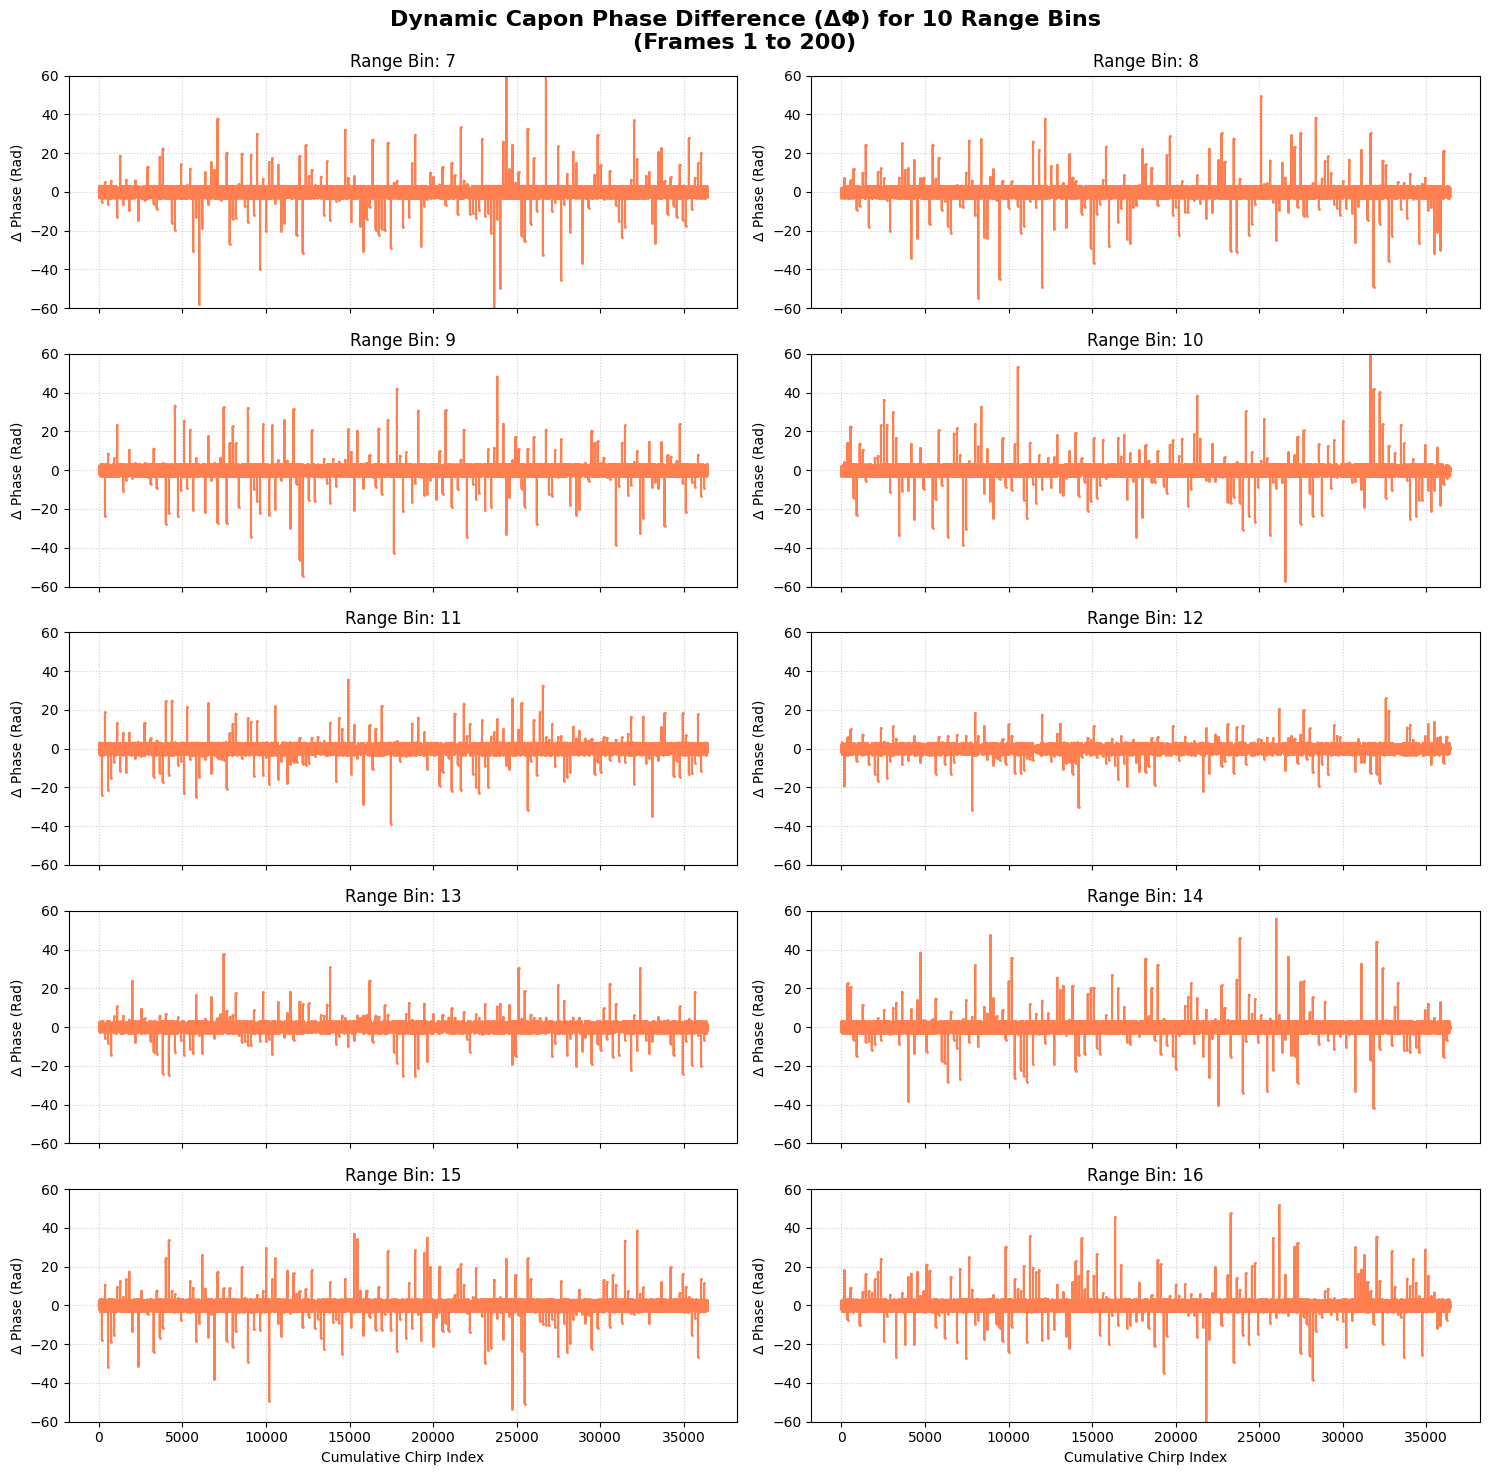

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import os

start_frame = 1
num_frames = 200

def extract_radar_cube(f_idx, data=loaded_adc_data):
    current_frame = data[f_idx - 1 : f_idx]
    adc_data = np.apply_along_axis(
        DCA1000.organize, 1, current_frame, 
        num_chirps=numChirpsPerFrame, 
        num_rx=numRxAntennas, 
        num_samples=numADCSamples
    )
    return dsp.range_processing(adc_data[0], window_type_1d=Window.BLACKMAN)

initial_cube = extract_radar_cube(start_frame)

_, selected_bins, _ = iterative_range_bins_detection(initial_cube, min_bin=min_b, max_bin=max_b)
pref_bins = [i for i in range(selected_bins[0]-5, selected_bins[0]+5)]

print(f"\nTracking dynamic Capon phase for {len(pref_bins)} Bins: {pref_bins}")
print(f"Processing frames {start_frame} to {start_frame + num_frames - 1}...")

phase_history = {bin_idx: [] for bin_idx in pref_bins}
scan_range_deg = 60
resolution_deg = 1
num_virtual_antennas = numTxAntennas * numRxAntennas   
num_vec, steering_vectors = gen_steering_vec(scan_range_deg, resolution_deg, num_virtual_antennas)
angles_grid = np.linspace(-scan_range_deg, scan_range_deg, num_vec)

for f_idx in range(start_frame, start_frame + num_frames):
    current_cube = extract_radar_cube(f_idx)
    _, _, rangeResult = iterative_range_bins_detection(current_cube, min_bin=min_b, max_bin=max_b)
    
    for current_bin in pref_bins:
        x_slice_current = rangeResult[:, :, :, current_bin].reshape(num_virtual_antennas, numLoopsPerFrame)
        capon_spectrum_current, capon_weights_current = aoa_capon(x_slice_current, steering_vectors, magnitude=True)
        peak_idx_current = np.argmax(capon_spectrum_current)
        dynamic_peak_angle = angles_grid[peak_idx_current] 
        w_opt_current = capon_weights_current[:, peak_idx_current]
        filtered_signal_current = np.dot(w_opt_current.conj().T, x_slice_current)
        phase_current = np.unwrap(np.angle(filtered_signal_current))
        phase_history[current_bin].extend(phase_current)

print("Processing complete. Generating phase difference plot...")

fig_top10, axes_top10 = plt.subplots(5, 2, figsize=(15, 15), sharex=True)
fig_top10.suptitle(f"Dynamic Capon Phase Difference (ΔΦ) for {len(pref_bins)} Range Bins\n(Frames {start_frame} to {start_frame + num_frames - 1})", 
                   fontsize=16, fontweight='bold')

for idx, current_bin in enumerate(pref_bins):
    row = idx // 2
    col = idx % 2
    ax = axes_top10[row, col]
    phase_diff = np.diff(phase_history[current_bin])
    
    ax.plot(phase_diff, color='coral', marker='.', markersize=2, linestyle='-')
    ax.set_title(f"Range Bin: {current_bin}")
    ax.set_ylim(-60,60)
    ax.set_ylabel("Δ Phase (Rad)") # Updated label
    ax.grid(True, linestyle=':', alpha=0.6)

for col in range(2):
    axes_top10[4, col].set_xlabel("Cumulative Chirp Index")

fig_top10.tight_layout()
save_path = os.path.join(save_dir, f"frames_{start_frame}_to_{start_frame + num_frames - 1}_dynamic_capon_phase_diff.png")
fig_top10.savefig(save_path)
plt.show()

# Signal classification(Test)

In [17]:
import numpy as np
from scipy.signal import savgol_filter

def classify_phase_signal_robust(phase_array, freq_ghz=77.0, chirp_rate_hz=18200.0):
    c = 3e8
    lambda_m = c / (freq_ghz * 1e9)
    chirp_time_s = 1.0 / chirp_rate_hz

    overall_phase_shift = np.max(phase_array) - np.min(phase_array)
    total_displacement_m = (overall_phase_shift * lambda_m) / (4 * np.pi)
    
    window_length = 21 
    if len(phase_array) < window_length:
        window_length = len(phase_array) if len(phase_array) % 2 != 0 else len(phase_array) - 1
        
    smoothed_phase = savgol_filter(phase_array, window_length=window_length, polyorder=3)

    chirp_step = 18
    if len(smoothed_phase) <= chirp_step:
        chirp_step = 1 

    phase_diff_18 = smoothed_phase[chirp_step:] - smoothed_phase[:-chirp_step]
    time_delta = chirp_step * chirp_time_s
    
    num_chunks = 10
    chunks = np.array_split(phase_diff_18, num_chunks) 
    
    chunk_max_velocities = []
    
    for chunk in chunks:
        if len(chunk) > 0:
            max_diff_in_chunk = np.max(np.abs(chunk))
            
            chunk_vel_mps = ((max_diff_in_chunk * lambda_m) / (4 * np.pi)) / time_delta
            chunk_max_velocities.append(chunk_vel_mps)
            
    avg_max_velocity_mps = np.mean(chunk_max_velocities) if chunk_max_velocities else 0.0

    VELOCITY_THRESHOLD = 1.0  
    DISPLACEMENT_THRESHOLD = 0.015 # 15 mm
    
    is_noise = (avg_max_velocity_mps > VELOCITY_THRESHOLD) or \
               (total_displacement_m > DISPLACEMENT_THRESHOLD)
               
    classification = "NOISE (Unphysical Kinematics)" if is_noise else "POTENTIAL VIBRATION"
    
    report = (
        f"--- Robust Kinematic Phase Analysis ---\n"
        f"Classification      : {classification}\n"
        f"Overall Phase Shift : {overall_phase_shift:.2f} rad\n"
        f"Total Displacement  : {total_displacement_m * 1000:.2f} mm\n"
        f"Avg Max Velocity    : {avg_max_velocity_mps:.2f} m/s (18-chirp, 10-chunk avg)\n"
        f"--------------------------------"
    )
    
    return is_noise, report

is_noise_dynamic, analysis_report = classify_phase_signal_robust(capon_filtered_phase_dynamic)
print(analysis_report)

--- Robust Kinematic Phase Analysis ---
Classification      : POTENTIAL VIBRATION
Overall Phase Shift : 13.96 rad
Total Displacement  : 4.33 mm
Avg Max Velocity    : 0.73 m/s (18-chirp, 10-chunk avg)
--------------------------------


# Noise cancellation test and plot

In [17]:
TARGET_BIN = 12      
REFERENCE_BIN = 25  

def extract_capon_phase_for_bin(radar_cube, target_bin, num_virtual_antennas, num_loops, steering_vecs, angles):
    x_slice = radar_cube[:, :, :, target_bin].reshape(num_virtual_antennas, num_loops)
    capon_spectrum, capon_weights = aoa_capon(x_slice, steering_vecs, magnitude=True)
    peak_idx = np.argmax(capon_spectrum)
    w_opt = capon_weights[:, peak_idx]
    
    filtered_signal = np.dot(w_opt.conj().T, x_slice)
    return np.unwrap(np.angle(filtered_signal))

phone_phase = extract_capon_phase_for_bin(rangeResult, TARGET_BIN, 
                                          num_virtual_antennas, numLoopsPerFrame, 
                                          steering_vectors, angles_grid)

static_reference_phase = extract_capon_phase_for_bin(rangeResult, REFERENCE_BIN, 
                                                     num_virtual_antennas, numLoopsPerFrame, 
                                                     steering_vectors, angles_grid)

cleaned_vibration_phase = phone_phase - static_reference_phase

print(f"Cleaned Peak-to-Peak Shift: {np.max(cleaned_vibration_phase) - np.min(cleaned_vibration_phase):.2f} radians")

Cleaned Peak-to-Peak Shift: 30.10 radians


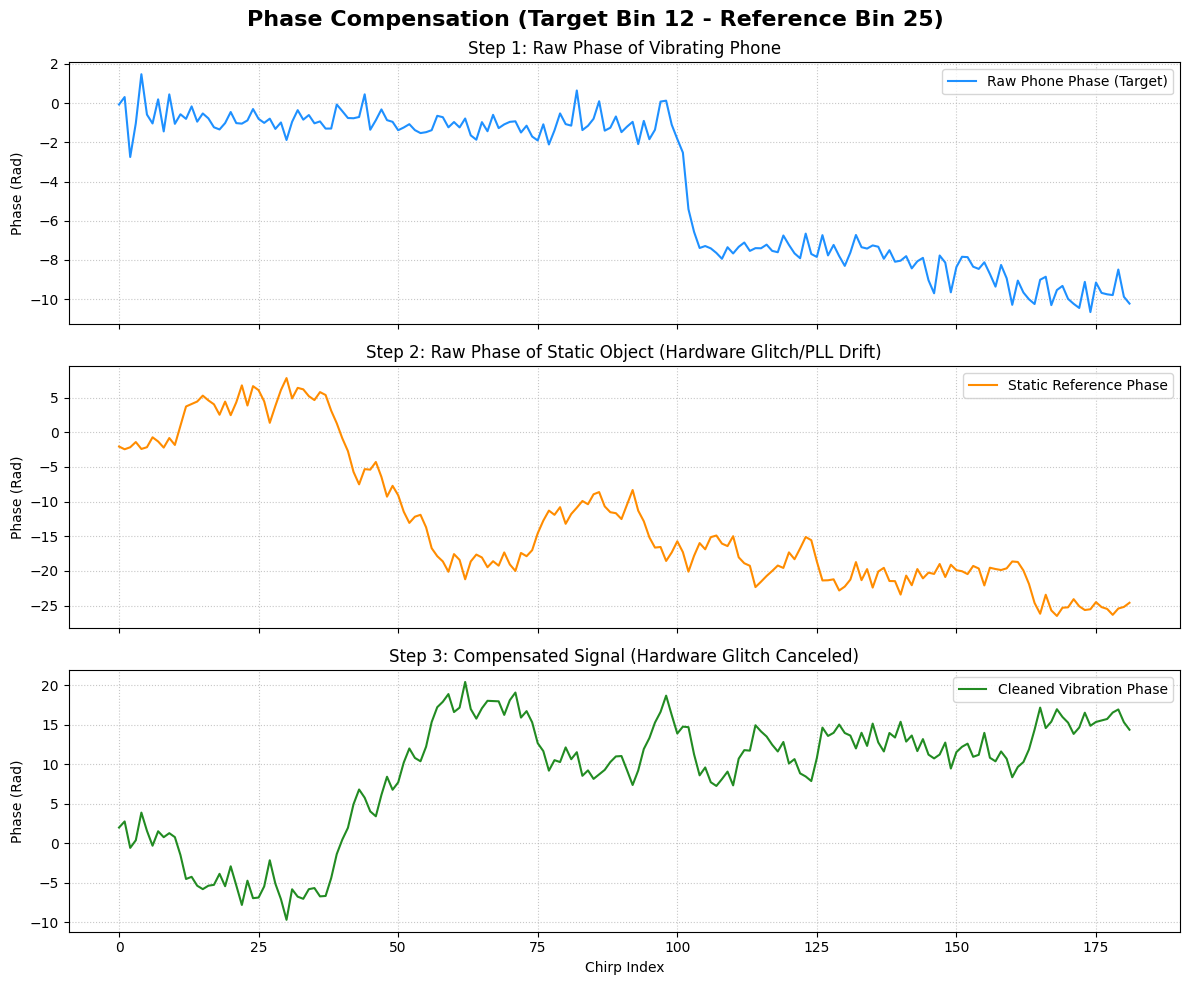

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle(f"Phase Compensation (Target Bin {TARGET_BIN} - Reference Bin {REFERENCE_BIN})", 
             fontsize=16, fontweight='bold')

# 1. Plot the Raw Target Phase (Vibration + Hardware Jitter + Noise)
axes[0].plot(phone_phase, color='dodgerblue', label='Raw Phone Phase (Target)')
axes[0].set_title("Step 1: Raw Phase of Vibrating Phone")
axes[0].set_ylabel("Phase (Rad)")
axes[0].grid(True, linestyle=':', alpha=0.7)
axes[0].legend(loc='upper right')

# 2. Plot the Reference Phase (Pure Hardware Jitter + Noise)
axes[1].plot(static_reference_phase, color='darkorange', label='Static Reference Phase')
axes[1].set_title("Step 2: Raw Phase of Static Object (Hardware Glitch/PLL Drift)")
axes[1].set_ylabel("Phase (Rad)")
axes[1].grid(True, linestyle=':', alpha=0.7)
axes[1].legend(loc='upper right')

# 3. Plot the Cleaned Result (Target - Reference)
axes[2].plot(cleaned_vibration_phase, color='forestgreen', linewidth=1.5, label='Cleaned Vibration Phase')
axes[2].set_title("Step 3: Compensated Signal (Hardware Glitch Canceled)")
axes[2].set_ylabel("Phase (Rad)")
axes[2].set_xlabel("Chirp Index")
axes[2].grid(True, linestyle=':', alpha=0.7)
axes[2].legend(loc='upper right')

plt.tight_layout()

# Save the plot if needed
# plt.savefig(os.path.join(save_dir, "phase_compensation_plot.png"))

plt.show()